<h1 style="text-align:center; font-size:40px;">
Ecommerce Retail Data Analysis
</h1>

<h3 style="text-align:center;">
Python | Pandas | Matplotlib
</h3>

In [123]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

%matplotlib inline

In [124]:
df = pd.read_csv('ecommerce_retail.csv', encoding='unicode_escape')
print("Dataset Shape:", df.shape)

Dataset Shape: (55825, 25)


In [125]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 55825 entries, 0 to 55824
Data columns (total 25 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   order_id                     55825 non-null  str    
 1   customer_id                  55825 non-null  str    
 2   customer_name                55825 non-null  str    
 3   product_id                   55825 non-null  str    
 4   product_name                 55825 non-null  str    
 5   category                     55825 non-null  str    
 6   quantity                     55825 non-null  float64
 7   unit_price_eur               55825 non-null  float64
 8   discount_pct                 55825 non-null  float64
 9   tax_rate                     55825 non-null  float64
 10  total_amount_eur             55825 non-null  float64
 11  payment_method               55825 non-null  str    
 12  payment_status               55825 non-null  str    
 13  order_date                 

In [126]:
df['order_date'] = pd.to_datetime(
    df['order_date'],
    format='mixed',
    errors='coerce'
)
df['delivery_date'] = pd.to_datetime(
    df['delivery_date'],
    format='mixed',
    errors='coerce'
)
df['year'] = df['order_date'].dt.year
print("Order Date Range:", df['order_date'].min(), "to", df['order_date'].max())
print("Years Available:", sorted(df['year'].dropna().unique()))

Order Date Range: 2023-01-01 00:00:00 to 2025-12-31 00:00:00
Years Available: [np.int32(2023), np.int32(2024), np.int32(2025)]


In [127]:
#Visualization 1 — Total Sales by Year

In [128]:
df['order_date'] = pd.to_datetime(df['order_date'], errors='coerce')
df['year'] = df['order_date'].dt.year

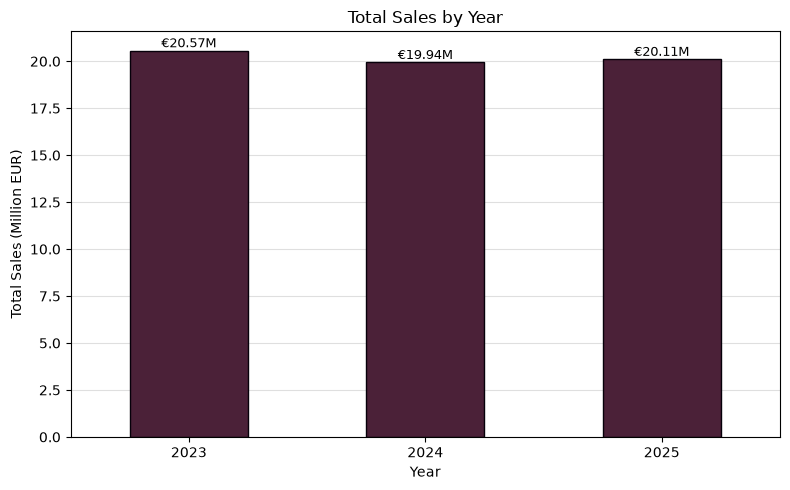

In [129]:
yearly_sales = df.groupby('year')['total_amount_eur'].sum()
yearly_sales_millions = yearly_sales / 1_000_000
fig, ax = plt.subplots(figsize=(8, 5))
yearly_sales_millions.plot(
    kind='bar',
    ax=ax,
    color='#4B2138',
    edgecolor='#06000a',
    linewidth=1
)
plt.title('Total Sales by Year')
plt.xlabel('Year')
plt.ylabel('Total Sales (Million EUR)')
plt.xticks(rotation=0)
ax.grid(
    axis='y',
    linestyle='-',
    alpha=0.4
)
ax.set_axisbelow(True)
for i, value in enumerate(yearly_sales_millions):
    ax.text(
        i,
        value + 0.02,
        f'€{value:.2f}M',
        ha='center',
        va='bottom',
        fontsize=9
    )
plt.tight_layout()
plt.show()

Total sales remained relatively stable between 2023 and 2025, with 2023 recording the highest annual sales.

In [130]:
#Visualization 2 — Sales by Product Category

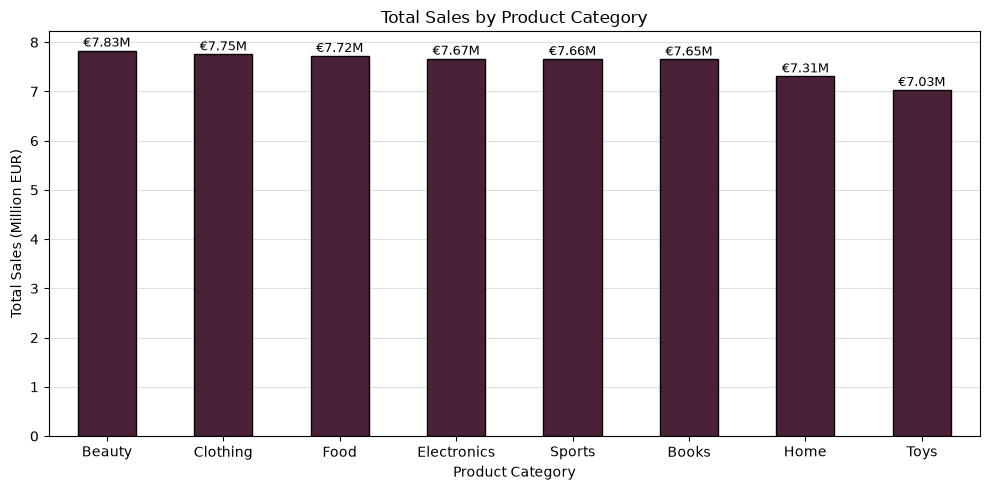

In [131]:
category_sales = (
    df.groupby('category')['total_amount_eur']
      .sum()
      .sort_values(ascending=False)
)
category_sales_millions = category_sales / 1_000_000
fig, ax = plt.subplots(figsize=(10, 5))
category_sales_millions.plot(kind='bar', ax=ax)
category_sales_millions.plot(
    kind='bar',
    ax=ax,
    color='#4B2138',
    edgecolor='#06000a',
    linewidth=1
)
plt.title('Total Sales by Product Category')
plt.xlabel('Product Category')
plt.ylabel('Total Sales (Million EUR)')
plt.xticks(rotation=0, ha='center')
ax.grid(
    axis='y',
    linestyle='-',
    alpha=0.4
)
ax.set_axisbelow(True)
for i, value in enumerate(category_sales_millions):
    ax.text(i, value + 0.02, f'€{value:.2f}M',
            ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

This chart shows which product categories contribute the most to overall sales and highlights differences in category-level performance.

In [132]:
#Visualization 3 — Top 10 Products by Sales

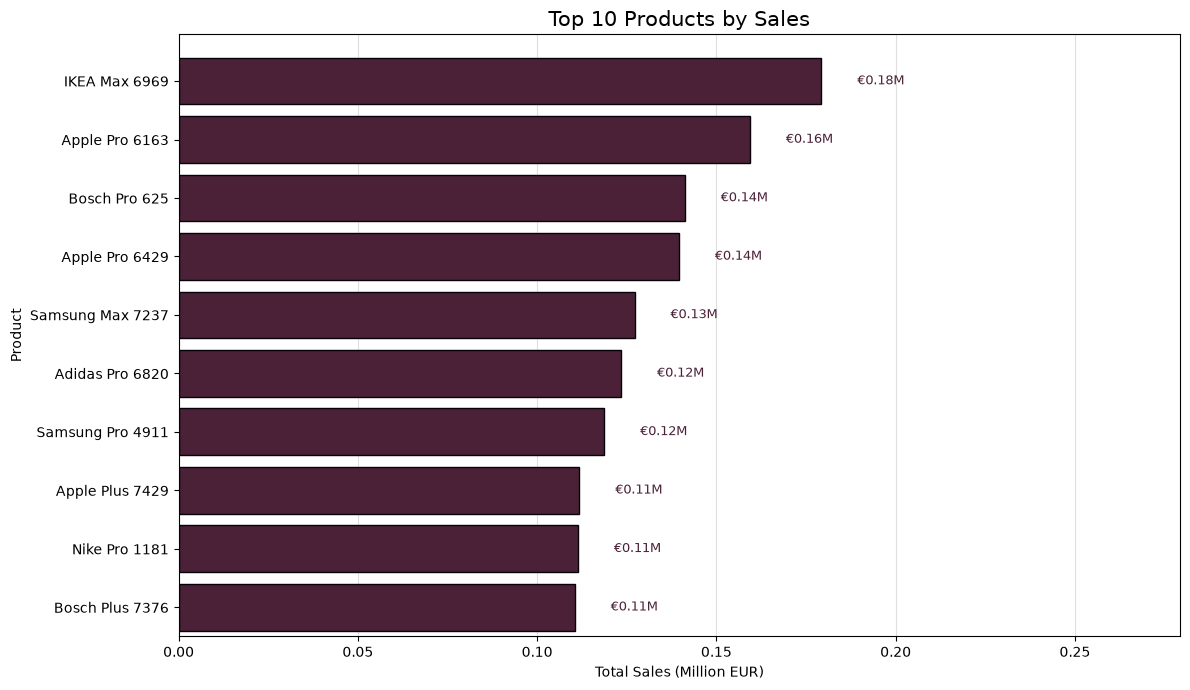

In [133]:
top_products = (
    df.groupby('product_name')['total_amount_eur']
      .sum()
      .sort_values(ascending=False)
      .head(10)
)
top_products_millions = top_products / 1_000_000
fig, ax = plt.subplots(figsize=(12, 7))
data = top_products_millions.sort_values()
bars = ax.barh(
    data.index,
    data.values,
    color='#4B2138',
    edgecolor='#06000a',
    linewidth=1
)
ax.grid(
    axis='x',
    linestyle='-',
    alpha=0.4
)
ax.set_axisbelow(True)
plt.title('Top 10 Products by Sales', fontsize=15)
plt.xlabel('Total Sales (Million EUR)')
plt.ylabel('Product')
for bar, value in zip(bars, data.values):
    ax.text(
        value + 0.01,
        bar.get_y() + bar.get_height() / 2,
        f'€{value:.2f}M',
        ha='left',
        va='center',
        fontsize=9,
        color='#4B2138'
    )
ax.set_axisbelow(True)
ax.set_xlim(0, data.max() + 0.10)
ax.set_ylim(-0.5, 9.8)
plt.tight_layout()
plt.show()

The chart identifies the top 10 products contributing the highest sales, helping highlight the products with the strongest revenue contribution.

In [134]:
#Visualization 4 — Sales by Customer Segment

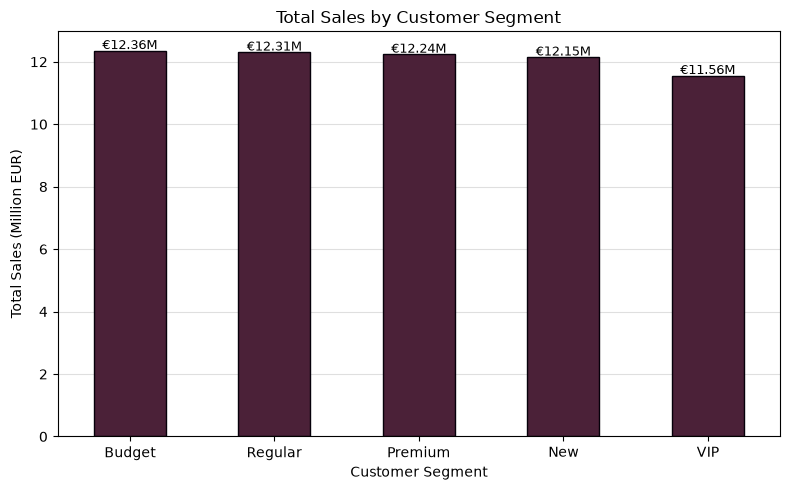

In [135]:
segment_sales = (
    df.groupby('customer_segment')['total_amount_eur']
      .sum()
      .sort_values(ascending=False)
)
segment_sales_millions = segment_sales / 1_000_000
plt.figure(figsize=(8, 5))
ax = segment_sales_millions.plot(kind='bar')
segment_sales_millions.plot(
    kind='bar',
    ax=ax,
    color='#4B2138',
    edgecolor='#06000a',
    linewidth=1
)
plt.title('Total Sales by Customer Segment')
plt.xlabel('Customer Segment')
plt.ylabel('Total Sales (Million EUR)')
plt.xticks(rotation=0)
ax.grid(
    axis='y',
    linestyle='-',
    alpha=0.4
)
ax.set_axisbelow(True)
for i, value in enumerate(segment_sales_millions):
    ax.text(i, value + 0.05, f'€{value:.2f}M',
            ha='center', fontsize=9)
plt.tight_layout()
plt.show()

This visualization compares sales across customer segments and shows which segments contribute most to overall revenue.

In [136]:
#Visualization 5 — Orders by Payment Method

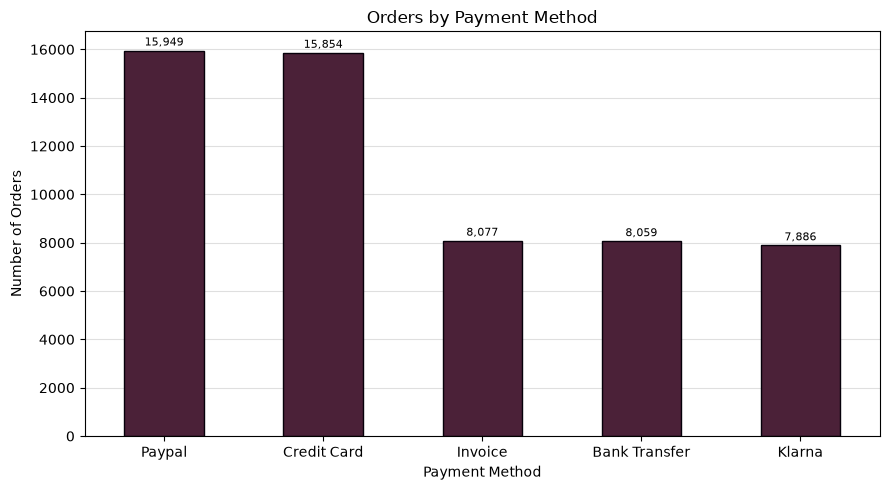

In [137]:
df['payment_method'] = (
    df['payment_method']
    .str.strip()
    .str.lower()
    .str.replace('_', ' ')
    .str.title()
)
payment_method_counts = df['payment_method'].value_counts()
fig, ax = plt.subplots(figsize=(9, 5))
payment_method_counts.plot(kind='bar', ax=ax)
payment_method_counts.plot(
    kind='bar',
    ax=ax,
    color='#4B2138',
    edgecolor='#06000a',
    linewidth=1
)
ax.grid(
    axis='y',
    linestyle='-',
    alpha=0.4
)
ax.set_axisbelow(True)
plt.title('Orders by Payment Method')
plt.xlabel('Payment Method')
plt.ylabel('Number of Orders')
plt.xticks(rotation=0, ha='center')
for i, value in enumerate(payment_method_counts):
    ax.text(i, value + 100, f'{value:,}',
            ha='center', va='bottom', fontsize=8)
plt.tight_layout()
plt.show()

The chart compares order volume across different payment methods and highlights the most frequently used payment options.

In [138]:
#Visualization 6 — Orders by Device Type

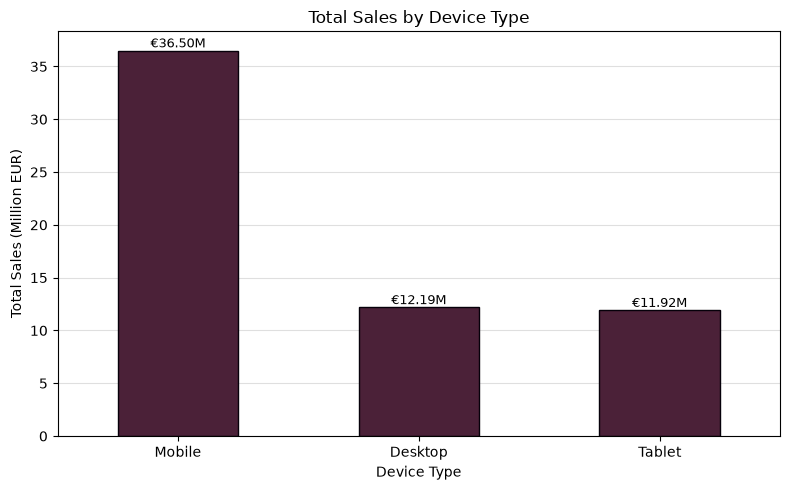

In [139]:
df['device_type'] = (
    df['device_type']
    .str.strip()
    .str.lower()
    .str.title()
)
device_sales = (
    df.groupby('device_type')['total_amount_eur']
      .sum()
      .sort_values(ascending=False)
)
device_sales_millions = device_sales / 1_000_000
fig, ax = plt.subplots(figsize=(8, 5))
device_sales_millions.plot(kind='bar', ax=ax)
device_sales_millions.plot(
    kind='bar',
    ax=ax,
    color='#4B2138',
    edgecolor='#06000a',
    linewidth=1
)
ax.grid(
    axis='y',
    linestyle='-',
    alpha=0.4
)
ax.set_axisbelow(True)
plt.title('Total Sales by Device Type')
plt.xlabel('Device Type')
plt.ylabel('Total Sales (Million EUR)')
plt.xticks(rotation=0)
for i, value in enumerate(device_sales_millions):
    ax.text(i, value + 0.02, f'€{value:.2f}M',
            ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.show()

This visualization shows how customers place orders across different device types, providing an overview of customer purchasing behavior.

In [140]:
#Visualization 7 — Average satisfaction score by category

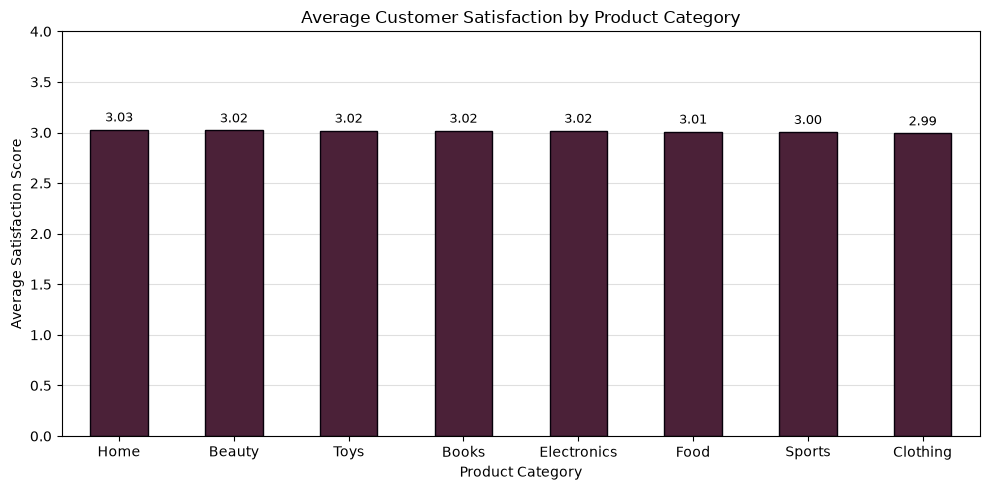

In [141]:
category_satisfaction = (
    df.groupby('category')['customer_satisfaction_score']
      .mean()
      .sort_values(ascending=False)
)
fig, ax = plt.subplots(figsize=(10, 5))
category_satisfaction.plot(kind='bar', ax=ax)
category_satisfaction.plot(
    kind='bar',
    ax=ax,
    color='#4B2138',
    edgecolor='#06000a',
    linewidth=1
)
ax.grid(
    axis='y',
    linestyle='-',
    alpha=0.4
)
ax.set_axisbelow(True)
plt.title('Average Customer Satisfaction by Product Category')
plt.xlabel('Product Category')
plt.ylabel('Average Satisfaction Score')
plt.xticks(rotation=0, ha='center')
plt.ylim(0, 4)
for i, value in enumerate(category_satisfaction):
    ax.text(
        i,
        value + 0.05,
        f'{value:.2f}',
        ha='center',
        va='bottom',
        fontsize=9
    )
plt.tight_layout()
plt.show()

The chart compares average customer satisfaction across product categories and highlights categories with relatively higher or lower satisfaction levels.

In [142]:
#Visualization 8 — Monthly Sales Trend

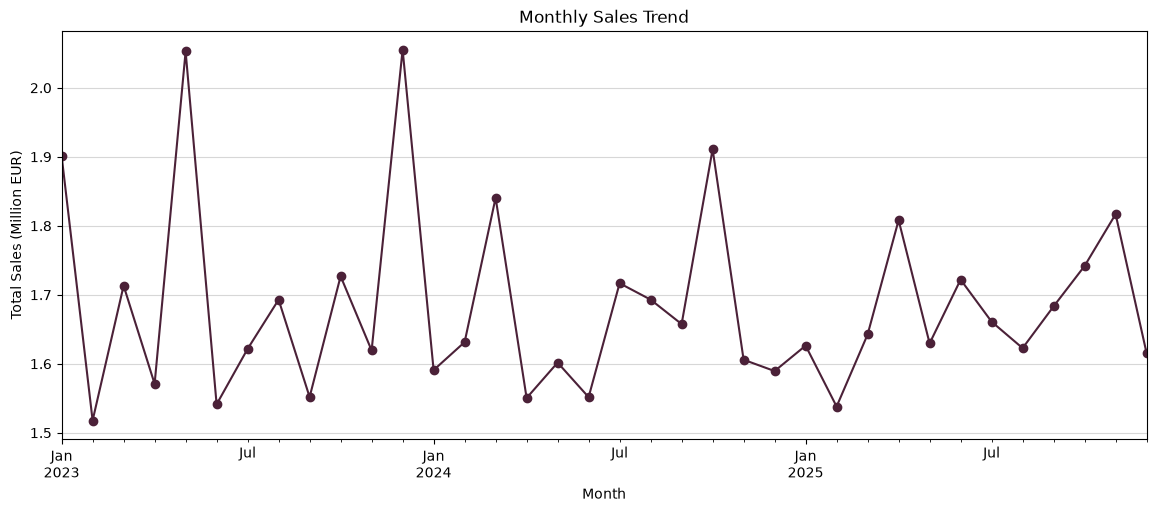

In [143]:
df['order_date'] = pd.to_datetime(df['order_date'], errors='coerce')
df['month'] = df['order_date'].dt.to_period('M')
monthly_sales = (
    df.groupby('month')['total_amount_eur']
      .sum()
)
monthly_sales_millions = monthly_sales / 1_000_000
fig, ax = plt.subplots(figsize=(14, 6))
monthly_sales_millions.plot(
    kind='line',
    marker='o',
    color='#4B2138',
    ax=ax
)
ax.grid(
    axis='y',
    linestyle='-',
    alpha=0.5,
)
plt.title('Monthly Sales Trend')
plt.xlabel('Month')
plt.ylabel('Total Sales (Million EUR)')
plt.xticks(rotation=0)
for i in range(0, len(monthly_sales_millions), 3):
    value = monthly_sales_millions.iloc[i]
    ax.annotate(
        f'€{value:.2f}M',
        (i, value),
        xytext=(0, 8),
        textcoords='offset points',
        ha='center',
        fontsize=8
    )
plt.subplots_adjust(bottom=0.20)
plt.show()

The monthly trend shows how sales fluctuate throughout the year and helps identify periods of higher and lower sales activity.

In [144]:
# Visualization 9 — Return Rate by Product Category

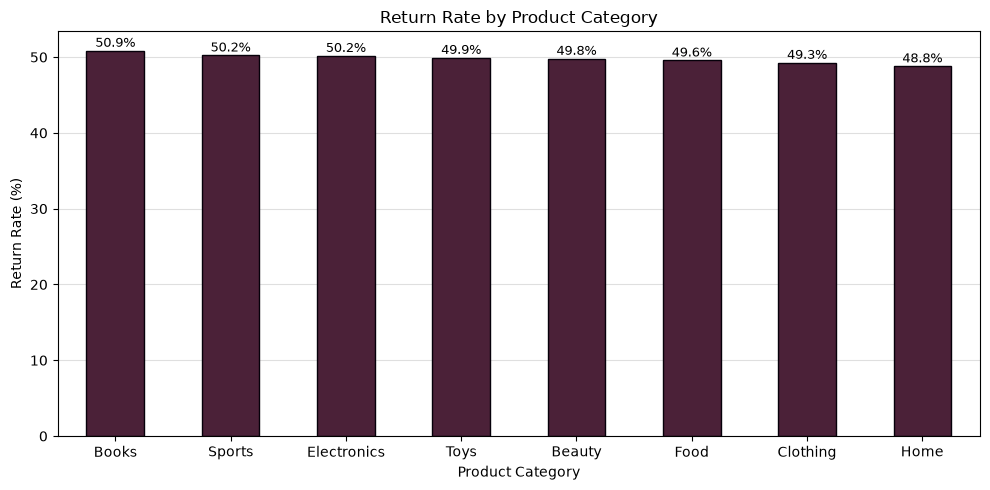

In [145]:
return_by_category = (
    df.groupby('category')['return_requested']
      .mean()
      .sort_values(ascending=False) * 100
)
fig, ax = plt.subplots(figsize=(10, 5))
return_by_category.plot(kind='bar', ax=ax)
return_by_category.plot(
    kind='bar',
    ax=ax,
    color='#4B2138',
    edgecolor='#06000a',
    linewidth=1
)
ax.grid(
    axis='y',
    linestyle='-',
    alpha=0.4,
)
ax.set_axisbelow(True)
plt.title('Return Rate by Product Category')
plt.xlabel('Product Category')
plt.ylabel('Return Rate (%)')
plt.xticks(rotation=0, ha='center')
for i, value in enumerate(return_by_category):
    ax.text(
        i,
        value + 0.1,
        f'{value:.1f}%',
        ha='center',
        va='bottom',
        fontsize=9
    )
plt.tight_layout()
plt.show()

This chart shows the distribution of completed, failed, pending, and refunded orders across different payment methods.

In [146]:
# Visualization 10 — Payment Status by Payment Method

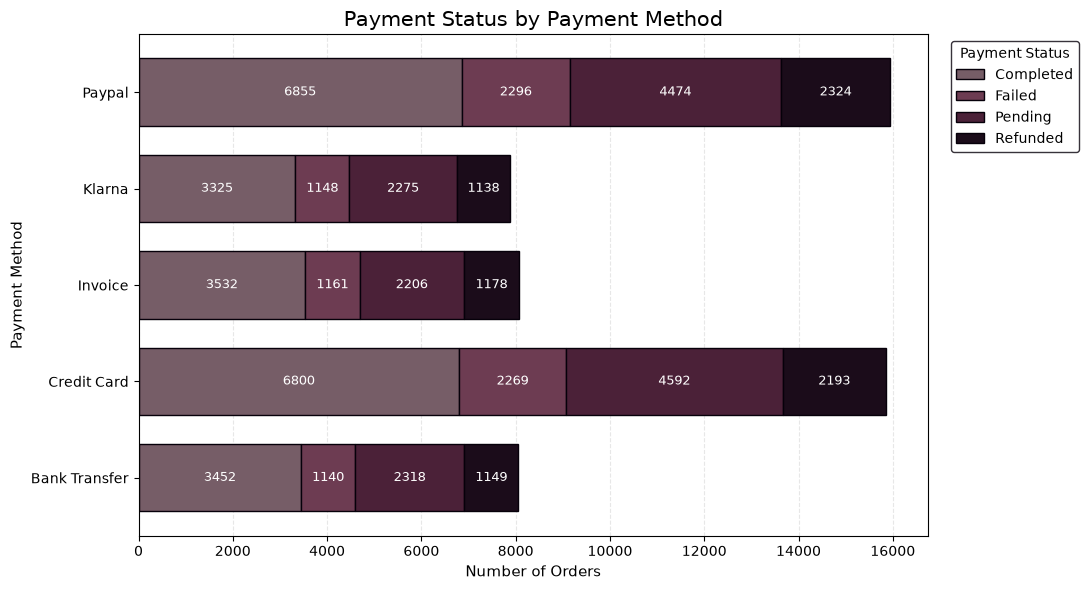

In [147]:
df['payment_status'] = (
    df['payment_status']
    .str.strip()
    .str.title()
)
payment_status = pd.crosstab(
    df['payment_method'],
    df['payment_status']
)
ax = payment_status.plot(
    kind='barh',
    stacked=True,
    figsize=(11, 6),
    width=0.7,
    color=['#765D67', '#6D3C52', '#4B2138', '#1B0C1A'],
    edgecolor='#06000a',
    linewidth=1
)
plt.title('Payment Status by Payment Method', fontsize=15)
plt.xlabel('Number of Orders', fontsize=11)
plt.ylabel('Payment Method', fontsize=11)
for container in ax.containers:
    labels = [
        f'{v.get_width():.0f}' if v.get_width() >= 500 else ''
        for v in container
    ]
    ax.bar_label(
        container,
        labels=labels,
        label_type='center',
        fontsize=9,
        color='white'
    )
plt.legend(
    title='Payment Status',
    bbox_to_anchor=(1.02, 1),
    loc='upper left',
    edgecolor='#06000a',
    linewidth=1
)
plt.grid(
    axis='x',
    linestyle='--',
    alpha=0.3
)
ax.set_axisbelow(True)
plt.tight_layout()
plt.show()

The visualization compares return rates across product categories and helps identify categories with relatively higher return activity.

In [148]:
# Visualization 11 — Customer Distribution by Segment

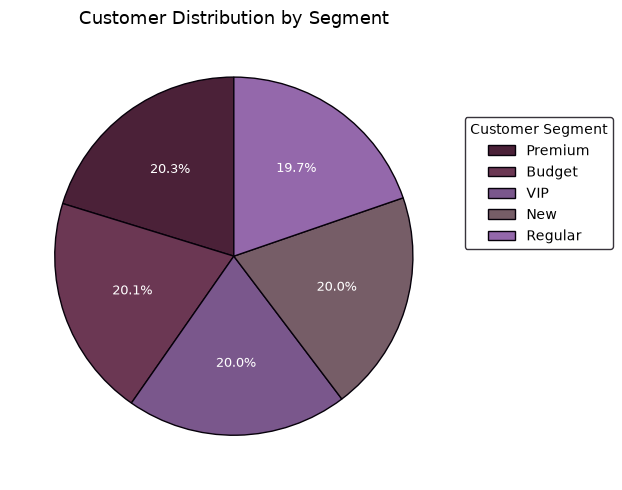

In [149]:
segment_counts = df['customer_segment'].value_counts()
plt.figure(figsize=(6, 5))
colors = ['#4B2138', '#6b3753', '#7a578c', '#765D67', '#9468ab']
plt.pie(
    segment_counts,
    autopct='%1.1f%%',
    startangle=90,
    colors=colors,
    textprops={'fontsize': 9, 'color': '#ffffff'},
    wedgeprops={
        'edgecolor': '#06000a',
        'linewidth': 1
    }
)
plt.title(
    'Customer Distribution by Segment',
    fontsize=13
)
plt.legend(
    segment_counts.index,
    title='Customer Segment',
    loc='lower left',
    bbox_to_anchor=(1, 0.5),
    edgecolor='#06000a',
    linewidth=1
)

plt.tight_layout()
plt.show()

The pie chart shows the distribution of customers across different customer segments, highlighting the relative share of each segment.

# Conclusion

This analysis provided an overview of ecommerce sales performance, customer behavior, payment methods, product performance, and customer satisfaction. The visualizations helped identify sales trends across years and months, top-performing products and categories, customer segment contributions, payment patterns, and product return rates.

Overall, the analysis demonstrates how Python, Pandas, and Matplotlib can be used to clean, analyze, and visualize ecommerce data to generate meaningful business insights.